# PINN으로 마이크로스트립 패치 안테나 전자기장 해석하기

물리 정보 신경망(PINN)은 인공지능이 물리 법칙을 지키면서 스스로 정답을 찾아가도록 가르치는 기술이다.  
일반 인공지능은 수많은 정답 데이터만 보고 학습하지만, PINN은 데이터가 없어도 "이 우주는 이런 물리 법칙(미분 방정식)을 따라야 해!"라는 규칙을 시험 문제집(손실 함수)에 직접 적어 알려주는 방식이다.  

여기서는 무선 통신(5G, Wi-Fi 등)에 가장 널리 쓰이는 **마이크로스트립 패치 안테나(Microstrip Patch Antenna)** 단면에서의 전자기장이 어떻게 형성이 되는지 PINN을 통해 직접 구현해본다.  

## 1. 입력 데이터 설명 (공간 도메인과 경계선)

인공지능 학습을 위해 두 가지 종류의 위치(좌표) 데이터를 준비해야 한다:  
1. **$X_u$ (경계선 데이터)**: 안테나 금속판 표면 위의 위치들이다. 접지판에서는 $V = 0$, 패치 안테나 판에서는 $V = 1.0$이라는 명확한 정답(경계 조건)을 이미 알고 있는 지점들이다.
2. **$X_f$ (내부 자유 공간 데이터)**: 안테나 주변의 텅 빈 공간들이다. 여기서는 정답을 모르지만, 전하가 없으므로 라플라스 방정식($\nabla^2 V = 0$)이라는 전자기 법칙을 반드시 만족해야 하는 지점들이다.  

우리가 다룰 공간은 가로 $x \in [-1.0, 1.0]$ 미터, 세로 $y \in [0.0, 1.0]$ 미터 크기의 2차원 사각형이다. 안테나는 꼭짓점 및 하부 접지판이 $y=0$에 있고, 신호를 쏘아주는 패치 안테나판이 $y=0.2, x \in [-0.4, 0.4]$ 위치에 있다.

### 가장자리 전계(Fringing Field)와 방사 원리

*   **가장자리 전계란?**  
    패치 안테나의 정중앙 영역 아래에서는 전기장이 수직 방향으로 똑바로 내려오지만, 패치 금속판의 양끝 가장자리(x = -0.4, x = 0.4) 부근에서는 전기장이 바깥 공간으로 둥글게 휘어져서 접지판으로 내려가게 된다. 이를 **가장자리 전계(Fringing Field)**라고 한다.

*   **왜 중요한가?**  
    마이크로스트립 패치 안테나가 우주 공간으로 전파를 쏴 보낼 수 있는 근본적인 원인이 바로 이 가장자리 전계의 대칭적 분포 때문이다. PINN 학습을 마친 후, 인공지능이 이 가장자리 전계의 곡선 형태를 정확하게 학습해 내는지 시각적으로 확인해 본다.

경계 조건 포인트 X_u 형태: torch.Size([598, 2])
내부 물리 포인트 X_f 형태: torch.Size([1910, 2])


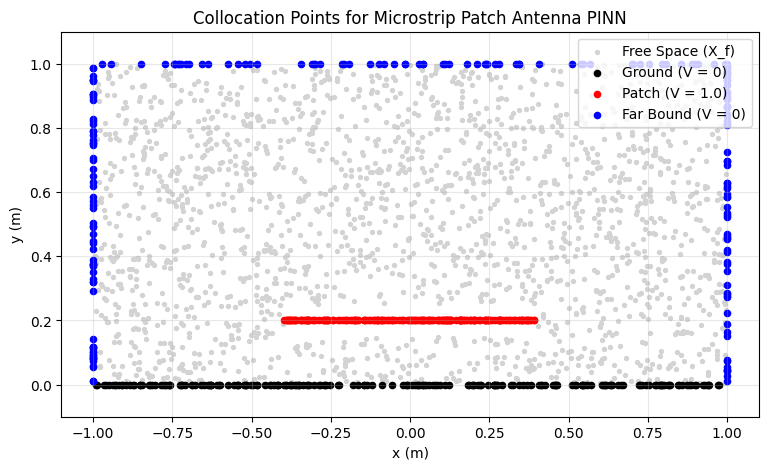

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import time

# 재현성을 위한 난수 시드 고정
torch.manual_seed(42)
np.random.seed(42)

# ==========================================
# 1. 도메인 및 데이터 생성
# ==========================================

N_u = 600   # 경계면 위의 샘플 점 개수
N_f = 2000  # 자유 공간 내부의 샘플 점 개수

# 1-1. 경계 조건 포인트 생성 (Ground, Patch, Far boundary)
# (1) 하부 접지판 (y = 0, V = 0)
x_g = np.random.uniform(-1.0, 1.0, (N_u // 3, 1))
y_g = np.zeros_like(x_g)
V_g = np.zeros_like(x_g)
X_g = np.hstack((x_g, y_g))

# (2) 패치 안테나 (y = 0.2, x in [-0.4, 0.4], V = 1.0)
x_p = np.random.uniform(-0.4, 0.4, (N_u // 3, 1))
y_p = np.ones_like(x_p) * 0.2
V_p = np.ones_like(x_p) * 1.0
X_p = np.hstack((x_p, y_p))

# (3) 외부 원역 가상 벽 (Left, Right, Top boundary: V = 0)
x_l = -np.ones((N_u // 9, 1))
y_l = np.random.uniform(0.0, 1.0, (N_u // 9, 1))
x_r = np.ones((N_u // 9, 1))
y_r = np.random.uniform(0.0, 1.0, (N_u // 9, 1))
x_t = np.random.uniform(-1.0, 1.0, (N_u // 9, 1))
y_t = np.ones_like(x_t)

X_far = np.vstack((np.hstack((x_l, y_l)), np.hstack((x_r, y_r)), np.hstack((x_t, y_t))))
V_far = np.zeros((X_far.shape[0], 1))

# 경계 데이터를 하나로 합칩니다
X_u = torch.FloatTensor(np.vstack((X_g, X_p, X_far)))
V_u = torch.FloatTensor(np.vstack((V_g, V_p, V_far)))

# 1-2. 자유 공간 내부 검증점 생성
x_f = np.random.uniform(-1.0, 1.0, (N_f, 1))
y_f = np.random.uniform(0.0, 1.0, (N_f, 1))
X_f_np = np.hstack((x_f, y_f))
# 패치 선상(y=0.2)에 겹치는 점들은 제거합니다
mask_patch = (np.abs(X_f_np[:, 0]) <= 0.4) & (np.abs(X_f_np[:, 1] - 0.2) < 0.05)
X_f_np = X_f_np[~mask_patch]
X_f = torch.FloatTensor(X_f_np)

# 미분값을 추적하기 위해 requires_grad를 활성화한다
X_f.requires_grad_(True)

print(f"경계 조건 포인트 X_u 형태: {X_u.shape}")
print(f"내부 물리 포인트 X_f 형태: {X_f.shape}")

# 도메인 샘플 점 시각화
plt.figure(figsize=(9,5))
plt.scatter(X_f[:,0].detach().numpy(), X_f[:,1].detach().numpy(), c='lightgray', s=8, label='Free Space (X_f)')
plt.scatter(X_g[:,0], X_g[:,1], c='black', s=20, label='Ground (V = 0)')
plt.scatter(X_p[:,0], X_p[:,1], c='red', s=20, label='Patch (V = 1.0)')
plt.scatter(X_far[:,0], X_far[:,1], c='blue', s=20, label='Far Bound (V = 0)')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Collocation Points for Microstrip Patch Antenna PINN')
plt.legend(loc='upper right')
plt.xlim(-1.1, 1.1)
plt.ylim(-0.1, 1.1)
plt.grid(True, alpha=0.3)
plt.show()


## 2. 하이퍼파라미터 설정 및 신경망 구조 시각화

물리 법칙이라는 까다로운 조건을 만족시키기 위해 총 5개의 은닉층과 은닉층당 64개의 노드로 신경망을 구성한다.  
활성화 함수로는 미분이 가능한 부드러운 하이퍼볼릭 탄젠트(Tanh) 함수를 사용한다.  
신경망은 최종적으로 2차원 공간 좌표 $(x,y)$를 받아서 그 위치의 1차원 전위 $V(x,y)$를 예측하므로 출력 크기는 **1**이 된다.

목표 에포크: 2000
은닉층 구조: [64, 64, 64, 64, 64]
활성화 함수: Tanh (Hyperbolic Tangent)


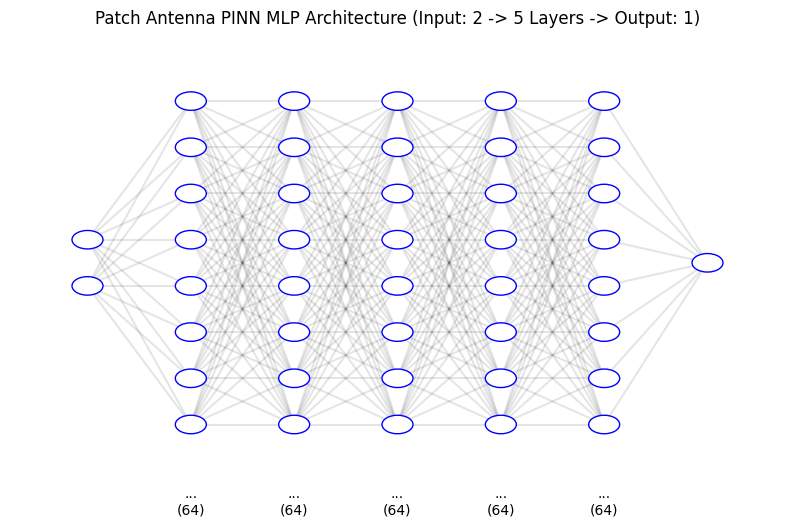

In [10]:
# ==========================================
# 2. 하이퍼파라미터 설정
# ==========================================

learning_rate = 1e-3 
epochs = 2000
hidden_layers = [64, 64, 64, 64, 64]

print(f"목표 에포크: {epochs}")
print(f"은닉층 구조: {hidden_layers}")
print(f"활성화 함수: Tanh (Hyperbolic Tangent)")

def draw_neural_net(input_size, hidden_layers, output_size):
    """
    설정된 파라미터에 따라 신경망 형태를 화면에 대략적으로 그린다
    """
    vis_hidden = [min(h, 8) for h in hidden_layers]
    layer_sizes = [input_size] + vis_hidden + [output_size]
    
    fig = plt.figure(figsize=(10, 6))
    ax = fig.gca()
    ax.axis('off')
    
    left, right, bottom, top = 0.1, 0.9, 0.1, 0.9
    v_spacing = (top - bottom) / float(max(layer_sizes))
    h_spacing = (right - left) / float(len(layer_sizes) - 1)
    
    # 노드를 시각화한다
    for n, layer_size in enumerate(layer_sizes):
        layer_top = v_spacing * (layer_size - 1) / 2. + (top + bottom) / 2.
        for m in range(layer_size):
            circle = plt.Circle((n * h_spacing + left, layer_top - m * v_spacing), v_spacing / 5.,
                                color='w', ec='b', zorder=4)
            ax.add_artist(circle)
            # 중간 부분은 축약하여 표시한다
            if m == layer_size - 1 and hidden_layers[0] > 8 and n > 0 and n < len(layer_sizes)-1:
                ax.text(n * h_spacing + left, layer_top - (m+1.5) * v_spacing, '\n...\n(64)', ha='center', va='center', fontsize=10)
            
    # 노드 사이의 연결선을 그린다
    for n, (layer_size_a, layer_size_b) in enumerate(zip(layer_sizes[:-1], layer_sizes[1:])):
        layer_top_a = v_spacing * (layer_size_a - 1) / 2. + (top + bottom) / 2.
        layer_top_b = v_spacing * (layer_size_b - 1) / 2. + (top + bottom) / 2.
        for m in range(layer_size_a):
            for o in range(layer_size_b):
                line = plt.Line2D([n * h_spacing + left, (n + 1) * h_spacing + left],
                                  [layer_top_a - m * v_spacing, layer_top_b - o * v_spacing], c='k', alpha=0.1)
                ax.add_artist(line)
    
    plt.title(f"Patch Antenna PINN MLP Architecture (Input: {input_size} -> {len(hidden_layers)} Layers -> Output: {output_size})")
    plt.show()

draw_neural_net(2, hidden_layers, 1)


## 3. 다이내믹 모델 생성 및 첫 순전파(Forward Pass) 시각화

설정한 조건에 맞춰 5층, 64노드의 단일(1자형) PINN 모델을 생성한다.  
이 모델은 위치 $(x,y)$를 받아서 전위 $V$를 바로 내놓는다.  
학습되지 않은 초기 상태에서 임의의 위치에 대해 예측을 진행해보고, 은닉층을 통과할 때의 신호 흐름을 히트맵으로 관찰한다.  

[첫 순전파 결과 (상위 10개 샘플)]
입력 좌표 X (x, y):
 [[-0.61542195  0.2842741 ]
 [-0.9182628   0.13382836]
 [-0.6621299   0.62955767]] ...

예측 전위 V:
 [[-0.14929023]
 [-0.1367324 ]
 [-0.16623724]] ...


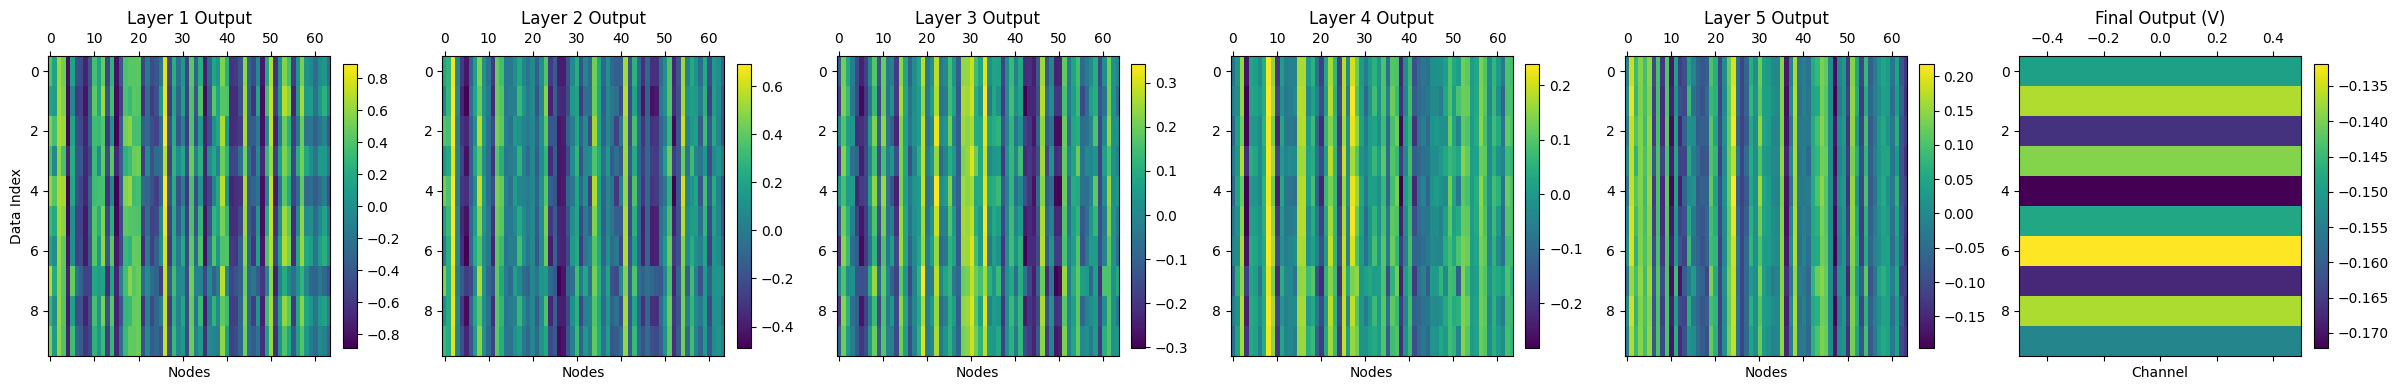

In [11]:
# ==========================================
# 3. 다이내믹 모델 생성 및 첫 순전파
# ==========================================

class TanhLayer(nn.Module):
    def __init__(self, in_features, out_features):
        super(TanhLayer, self).__init__()
        self.linear = nn.Linear(in_features, out_features)
        
    def forward(self, x):
        return torch.tanh(self.linear(x))

class DynamicTanhPINN(nn.Module):
    def __init__(self, input_size, hidden_layers, output_size):
        super(DynamicTanhPINN, self).__init__()
        self.layers = nn.ModuleList()
        
        # 입력 레이어를 구성한다
        self.layers.append(TanhLayer(input_size, hidden_layers[0]))
        
        # 은닉 레이어들을 구성한다
        for i in range(len(hidden_layers)-1):
            self.layers.append(TanhLayer(hidden_layers[i], hidden_layers[i+1]))
            
        # 최종 출력 레이어는 선형(Linear)이다 (활성화 함수가 없다)
        self.output_layer = nn.Linear(hidden_layers[-1], output_size)
            
    def forward(self, x):
        activations = []
        out = x
        for layer in self.layers:
            out = layer(out)
            activations.append(out)
        out = self.output_layer(out)
        activations.append(out)
        # 최종 예측값과 각 은닉 레이어의 활성화 상태를 반환한다
        return out, activations

# 1자형 단일 네트워크 모델을 생성한다
model = DynamicTanhPINN(input_size=2, hidden_layers=hidden_layers, output_size=1)

# 첫 순전파 수행 (시각화를 위해 X_f 중 상위 10개의 데이터 샘플만 사용한다)
sample_X = X_f[:10]
predictions, activations = model(sample_X)

print("[첫 순전파 결과 (상위 10개 샘플)]")
print("입력 좌표 X (x, y):\n", sample_X.detach().numpy()[:3], "...\n")
print("예측 전위 V:\n", predictions.detach().numpy()[:3], "...")

# 데이터 레이어 변화 시각화
fig, axes = plt.subplots(1, len(activations), figsize=(4 * len(activations), 4))
for i, (act, ax) in enumerate(zip(activations, axes)):
    cax = ax.matshow(act.detach().numpy(), cmap='viridis', aspect='auto')
    title = f"Layer {i+1} Output" if i < len(activations)-1 else "Final Output (V)"
    ax.set_title(title)
    ax.set_xlabel("Nodes" if i < len(activations)-1 else "Channel")
    if i == 0: ax.set_ylabel("Data Index")
    fig.colorbar(cax, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


## 4. 오차(Loss) 계산 과정 시각화 (PINN의 핵심)

인공지능이 정답을 찾아가도록 유도하는 손실 함수(Loss)를 계산한다.  
PINN의 최종 손실 함수는 **경계 조건 오차(Loss_BC)**와 **물리 법칙 오차(Loss_PDE)**의 단순 가중합으로 정의된다.  

$$\text{Total Loss} = w_{bc} \cdot \text{Loss_BC} + \text{Loss_PDE}$$

1. **`Loss_BC` (경계 조건 손실)**:  
   패치 표면($X_u$)의 실제 전위 정답과 인공지능 예측값의 차이(MSE)를 의미한다.  
2. **`Loss_PDE` (물리 법칙 손실)**:  
   자유 공간 내부($X_f$)에서는 전위가 아래의 라플라스 방정식을 완벽히 만족해야 한다:  
   $$\text{Residual } V = \frac{\partial^2 V}{\partial x^2} + \frac{\partial^2 V}{\partial y^2} = 0$$
   이 공식이 0이 되지 않고 어긋나는 정도를 의미한다.  

PyTorch의 자동 미분 기능(`torch.autograd.grad`)을 사용하여 공간에 대한 1차 미분 및 2차 미분 값을 계산해본다.  

In [12]:
# ==========================================
# 4. 오차(Loss) 계산 과정 및 편미분 시각화
# ==========================================

# 계산 흐름을 보여주기 위해 샘플 5개만 임의로 추출한다
X_f_sample = X_f[:5]
u_pred_sample, _ = model(X_f_sample)

V_sample = u_pred_sample[:, 0:1]

# 1. 자동 미분을 통한 1차 공간 미분 (dV/dx, dV/dy)
grad_V = torch.autograd.grad(V_sample, X_f_sample, grad_outputs=torch.ones_like(V_sample), create_graph=True)[0]
V_x = grad_V[:, 0:1]
V_y = grad_V[:, 1:2]

# 2. 자동 미분을 통한 2차 공간 미분 (d2V/dx2, d2V/dy2)
grad_V_x = torch.autograd.grad(V_x, X_f_sample, grad_outputs=torch.ones_like(V_x), create_graph=True)[0]
V_xx = grad_V_x[:, 0:1]
grad_V_y = torch.autograd.grad(V_y, X_f_sample, grad_outputs=torch.ones_like(V_y), create_graph=True)[0]
V_yy = grad_V_y[:, 1:2]
laplacian_sample = V_xx + V_yy

Loss_PDE_sample = torch.mean(laplacian_sample**2)

print("--- 2차 미분 및 라플라스 방정식 잔차 연산 추적 (첫 5개 샘플) ---")
print("1. V 예측값:\n", V_sample.detach().numpy())
print("2. V의 x축 방향 1차 미분값 (V_x):\n", V_x.detach().numpy())
print("3. V의 2차 라플라시안 미분값 (V_xx + V_yy):\n", laplacian_sample.detach().numpy())
print(f"\n물리 법칙 만족 오차(Loss_PDE, 0에 가까울수록 정답): {Loss_PDE_sample.item():.6f}")

# 전체 학습에서 호출할 Loss_PDE 계산 함수를 정의한다
def calc_pde_loss(model_net, x_points):
    pred, _ = model_net(x_points)
    grad_V = torch.autograd.grad(pred, x_points, grad_outputs=torch.ones_like(pred), create_graph=True)[0]
    dV_dx = grad_V[:, 0:1]
    dV_dy = grad_V[:, 1:2]
    
    grad_dV_dx = torch.autograd.grad(dV_dx, x_points, grad_outputs=torch.ones_like(dV_dx), create_graph=True)[0]
    d2V_dx2 = grad_dV_dx[:, 0:1]
    
    grad_dV_dy = torch.autograd.grad(dV_dy, x_points, grad_outputs=torch.ones_like(dV_dy), create_graph=True)[0]
    d2V_dy2 = grad_dV_dy[:, 1:2]
    
    laplacian = d2V_dx2 + d2V_dy2
    loss_pde = torch.mean(laplacian**2)
    return loss_pde


--- 2차 미분 및 라플라스 방정식 잔차 연산 추적 (첫 5개 샘플) ---
1. V 예측값:
 [[-0.14929023]
 [-0.1367324 ]
 [-0.16623724]
 [-0.1393618 ]
 [-0.17210048]]
2. V의 x축 방향 1차 미분값 (V_x):
 [[-0.01501692]
 [-0.01435634]
 [-0.01414536]
 [-0.01423283]
 [-0.01324157]]
3. V의 2차 라플라시안 미분값 (V_xx + V_yy):
 [[ 0.01265662]
 [-0.00510058]
 [ 0.0239277 ]
 [ 0.00915007]
 [ 0.02789669]]

물리 법칙 만족 오차(Loss_PDE, 0에 가까울수록 정답): 0.000324


## 5. 역전파(Backpropagation) 및 가중치 업데이트 시각화

계산된 총 오차(Total Loss)를 모델 전체에 거꾸로 전달하여 각 연결 가중치가 오차를 줄이도록 갱신한다.  
경사하강법 및 최신 최적화 알고리즘인 `Adam`을 사용하여 가중치를 조절한다.  
학습 전과 후, 인공지능 모델의 첫 번째 층 연결 강도(가중치)가 어떻게 변화하는지 히트맵으로 대조해본다.  

[1 에포크 학습 후의 Loss 결과]
Loss_BC (경계 조건 오차): 0.460426
Loss_PDE (물리 법칙 오차): 0.001118
Total Loss: 2.303246



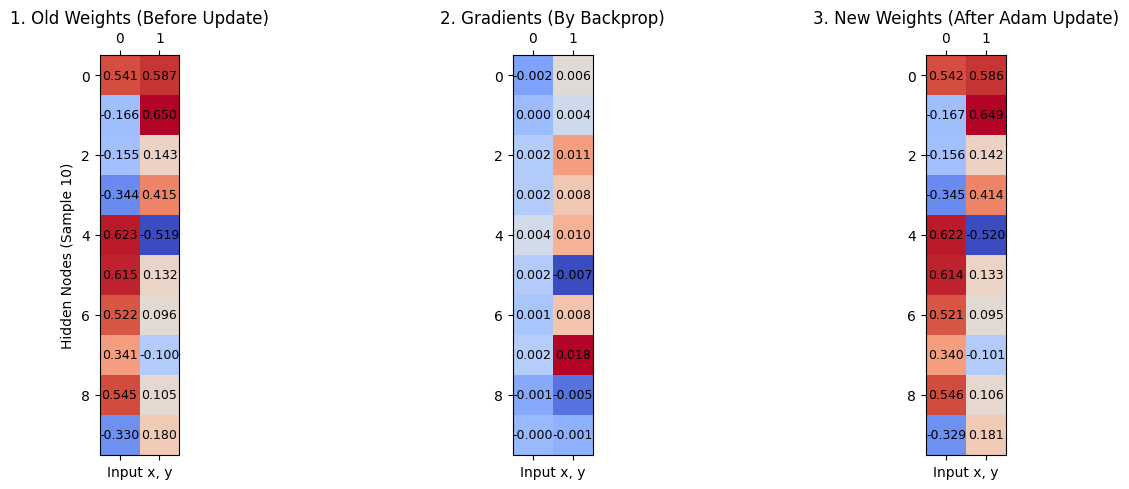

In [13]:
# ==========================================
# 5. 역전파 및 가중치 업데이트
# ==========================================

optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# 가중치를 업데이트하기 전 상태를 백업한다
old_weights = model.layers[0].linear.weight.data[:10, :].clone().numpy()

# 경계 조건 손실(Loss_BC)과 물리 법칙 손실(Loss_PDE)을 합쳐 전체 손실을 계산한다 (BC 가중치는 5.0)
u_pred_bc, _ = model(X_u)
Loss_BC = nn.MSELoss()(u_pred_bc, V_u)
Loss_PDE = calc_pde_loss(model, X_f)
total_loss = 5.0 * Loss_BC + Loss_PDE

# 역전파를 수행하여 가중치 조절 방향을 찾는다
optimizer.zero_grad() # 누적된 미분값 초기화
total_loss.backward() # 역전파 계산

# 기울기 값을 획득한다
gradients = model.layers[0].linear.weight.grad[:10, :].numpy()

# 가중치를 실질적으로 조절한다
optimizer.step()

# 업데이트된 후의 가중치를 획득한다
new_weights = model.layers[0].linear.weight.data[:10, :].numpy()

print(f"[1 에포크 학습 후의 Loss 결과]")
print(f"Loss_BC (경계 조건 오차): {Loss_BC.item():.6f}")
print(f"Loss_PDE (물리 법칙 오차): {Loss_PDE.item():.6f}")
print(f"Total Loss: {total_loss.item():.6f}\n")

# 가중치 변경 정보를 히트맵으로 그린다
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

def plot_heatmap(ax, data, title):
    cax = ax.matshow(data, cmap='coolwarm')
    for (row, col), val in np.ndenumerate(data):
        ax.text(col, row, f"{val:.3f}", ha='center', va='center', color='black', fontsize=9)
    ax.set_title(title)
    ax.set_xlabel("Input x, y")
    if title.startswith("1"):
        ax.set_ylabel("Hidden Nodes (Sample 10)")

plot_heatmap(axes[0], old_weights, "1. Old Weights (Before Update)")
plot_heatmap(axes[1], gradients, "2. Gradients (By Backprop)")
plot_heatmap(axes[2], new_weights, "3. New Weights (After Adam Update)")

plt.tight_layout()
plt.show()


## 6. 업데이트 된 결과와 에포크 간 오차 비교

가중치가 딱 1회 조절된 시점에서 오차가 실제로 얼마나 감소했는지 점검한다.  
경계 조건(Loss_BC)과 물리 법칙(Loss_PDE)은 서로 충돌할 수도 있어서, 학습 초반에는 두 오차의 균형을 맞추며 전체 오차가 서서히 줄어든다.  

Epoch 1 전체 오차: 2.303246 (Loss_BC: 0.460426, Loss_PDE: 0.001118)
Epoch 2 전체 오차: 1.970050 (Loss_BC: 0.393974, Loss_PDE: 0.000177)
오차 감소량: 0.333197



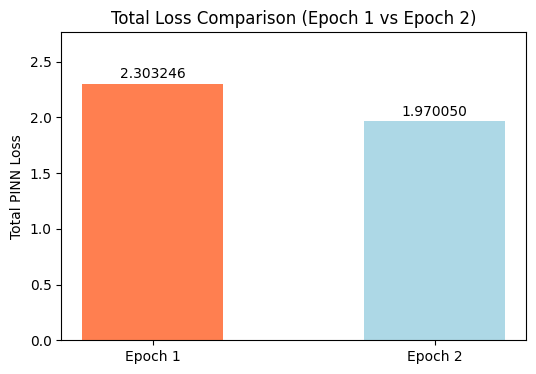

In [14]:
# ==========================================
# 6. 두 번째 순전파 및 오차 비교
# ==========================================

u_pred_bc_new, _ = model(X_u)

# 갱신된 가중치 상태로 두 종류의 손실 값을 다시 구한다
new_Loss_BC = nn.MSELoss()(u_pred_bc_new, V_u)
new_Loss_PDE = calc_pde_loss(model, X_f)
new_total_loss = 5.0 * new_Loss_BC + new_Loss_PDE

loss_epoch_1 = total_loss.item()
loss_epoch_2 = new_total_loss.item()

print(f"Epoch 1 전체 오차: {loss_epoch_1:.6f} (Loss_BC: {Loss_BC.item():.6f}, Loss_PDE: {Loss_PDE.item():.6f})")
print(f"Epoch 2 전체 오차: {loss_epoch_2:.6f} (Loss_BC: {new_Loss_BC.item():.6f}, Loss_PDE: {new_Loss_PDE.item():.6f})")
print(f"오차 감소량: {loss_epoch_1 - loss_epoch_2:.6f}\n")

# 막대 그래프로 오차 감소 수준을 보여준다
fig, ax = plt.subplots(figsize=(6, 4))
epochs_labels = ['Epoch 1', 'Epoch 2']
losses = [loss_epoch_1, loss_epoch_2]

bars = ax.bar(epochs_labels, losses, color=['coral', 'lightblue'], width=0.5)

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + (yval*0.01), f'{yval:.6f}', ha='center', va='bottom')

ax.set_ylabel('Total PINN Loss')
ax.set_title('Total Loss Comparison (Epoch 1 vs Epoch 2)')
ax.set_ylim(0, max(losses) * 1.2)
plt.show()


## 7. 본격적인 학습 : 패치 안테나 전위 학습 (Potential Learning)

설정된 반복 횟수(`epochs=2000`)에 걸쳐 모델을 완전히 학습시킨다.  
학습을 다 마친 인공지능은 수치해석 기법 없이도 임의의 위치에 대한 정전기적 전위 값을 직접 정확하게 도출해 낼 수 있다.

--- [1단계] 경계 조건 사전 학습 시작 (1000 에포크) ---
Epoch [ 200/1000], BC Loss: 2.173089e-03
Epoch [ 400/1000], BC Loss: 9.834534e-04
Epoch [ 600/1000], BC Loss: 5.690522e-04
Epoch [ 800/1000], BC Loss: 5.569716e-04
Epoch [1000/1000], BC Loss: 1.446422e-04

--- [2단계] L-BFGS 물리 법칙 결합 학습 시작 ---
Step [ 1/40], Total Loss: 1.310446e+01 (BC: 1.022963e-01, PDE: 2.874827e+00)
Step [ 2/40], Total Loss: 6.872750e+00 (BC: 4.188976e-02, PDE: 2.683775e+00)
Step [ 3/40], Total Loss: 3.636192e+00 (BC: 2.850637e-02, PDE: 7.855554e-01)
Step [ 4/40], Total Loss: 2.003859e+00 (BC: 1.310390e-02, PDE: 6.934687e-01)
Step [ 5/40], Total Loss: 1.209900e+00 (BC: 6.893188e-03, PDE: 5.205810e-01)
Step [ 6/40], Total Loss: 8.438212e-01 (BC: 4.786756e-03, PDE: 3.651456e-01)
Step [ 7/40], Total Loss: 6.668435e-01 (BC: 4.115994e-03, PDE: 2.552442e-01)
Step [ 8/40], Total Loss: 5.472647e-01 (BC: 3.481528e-03, PDE: 1.991120e-01)
Step [ 9/40], Total Loss: 4.657897e-01 (BC: 2.911294e-03, PDE: 1.746603e-01)
Step [10/40], Total Loss:

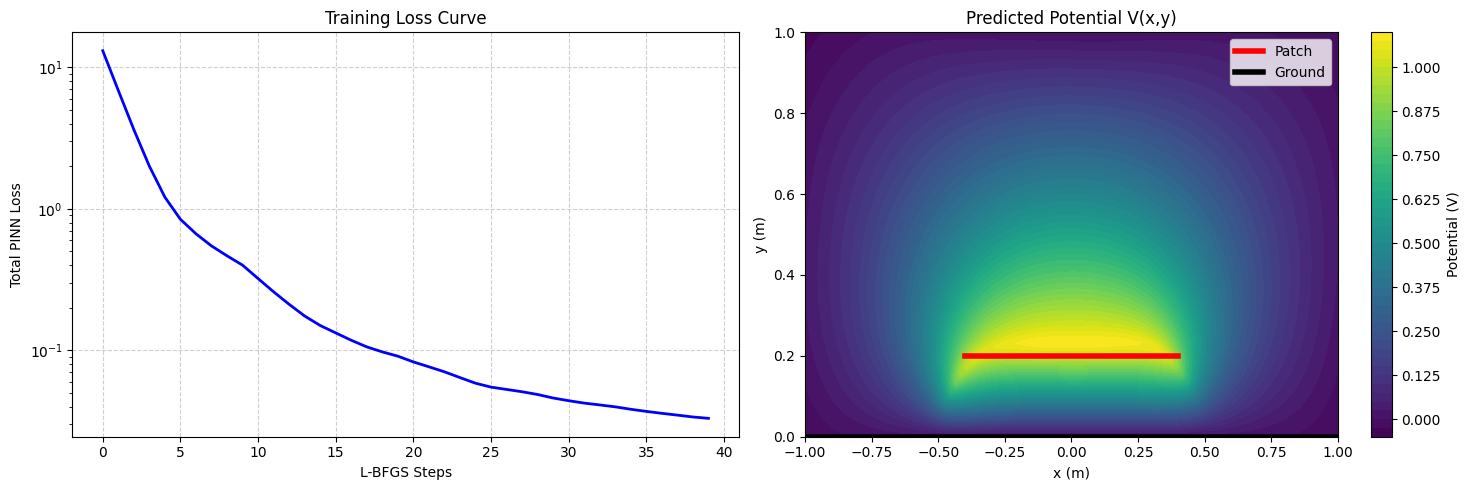

In [15]:
# ==========================================
# 7. 반복 학습 수행 및 결과 시각화 (전위)
# ==========================================

# 본격적인 학습을 위해 완전히 깨끗한 새 모델을 초기화한다
model_final = DynamicTanhPINN(input_size=2, hidden_layers=hidden_layers, output_size=1)

loss_history_final = []
start_time = time.time()

# 7-1. 1단계: 경계 조건(BC) 사전 학습 (Pre-training)
# 물리 법칙을 가하기 전에 경계 조건을 먼저 모델에게 가르칩니다.
print("--- [1단계] 경계 조건 사전 학습 시작 (1000 에포크) ---")
optimizer_pre = optim.Adam(model_final.parameters(), lr=1e-3)
for epoch in range(1000):
    optimizer_pre.zero_grad()
    u_pred_bc, _ = model_final(X_u)
    Loss_BC = nn.MSELoss()(u_pred_bc, V_u)
    Loss_BC.backward()
    optimizer_pre.step()
    if (epoch + 1) % 200 == 0:
        print(f"Epoch [{epoch+1:4d}/1000], BC Loss: {Loss_BC.item():.6e}")

# 7-2. 2단계: L-BFGS 옵티마이저를 사용한 물리 법칙(PDE) 결합 학습
# 2차 최적화 알고리즘인 L-BFGS를 사용하여 매우 높은 정확도로 물리 법칙을 수렴시킵니다.
print("\n--- [2단계] L-BFGS 물리 법칙 결합 학습 시작 ---")
optimizer_final = optim.LBFGS(model_final.parameters(), lr=0.1, max_iter=50, history_size=100)

# L-BFGS는 에포크 개념이 일반 Optimizer와 다르므로 40번의 스텝(Step)으로 학습을 진행합니다.
for epoch in range(40):
    def closure():
        optimizer_final.zero_grad()
        u_pred_bc, _ = model_final(X_u)
        Loss_BC = nn.MSELoss()(u_pred_bc, V_u)
        Loss_PDE = calc_pde_loss(model_final, X_f)
        loss = 100.0 * Loss_BC + Loss_PDE # BC 가중치와 PDE 균형 결합
        loss.backward()
        return loss
    
    optimizer_final.step(closure)
    
    # 진행도 및 오차 출력
    u_pred_bc_val, _ = model_final(X_u)
    Loss_BC_val = nn.MSELoss()(u_pred_bc_val, V_u).item()
    Loss_PDE_val = calc_pde_loss(model_final, X_f).item()
    total_loss_val = 100.0 * Loss_BC_val + Loss_PDE_val
    loss_history_final.append(total_loss_val)
    
    print(f"Step [{epoch+1:2d}/40], Total Loss: {total_loss_val:.6e} (BC: {Loss_BC_val:.6e}, PDE: {Loss_PDE_val:.6e})")

print(f"\n전위 학습 완료! (소요 시간: {time.time() - start_time:.2f}초)")

# 학습 경과 그래프와 전위 히트맵 시각화 패널
fig = plt.figure(figsize=(15, 5))

# 1. Loss 곡선 시각화
ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(loss_history_final, color='blue', linewidth=2)
ax1.set_yscale('log')
ax1.set_title('Training Loss Curve')
ax1.set_xlabel('L-BFGS Steps')
ax1.set_ylabel('Total PINN Loss')
ax1.grid(True, linestyle='--', alpha=0.6)

# 2. 예측된 전위 V(x,y) 히트맵
ax2 = fig.add_subplot(1, 2, 2)
x_grid = np.linspace(-1.0, 1.0, 100)
y_grid = np.linspace(0.0, 1.0, 100)
X_mesh, Y_mesh = np.meshgrid(x_grid, y_grid)
grid_tensor = torch.FloatTensor(np.c_[X_mesh.ravel(), Y_mesh.ravel()])

with torch.no_grad():
    V_pred, _ = model_final(grid_tensor)
V_pred = V_pred.numpy().reshape(X_mesh.shape)

contour = ax2.contourf(X_mesh, Y_mesh, V_pred, levels=50, cmap='viridis')
fig.colorbar(contour, ax=ax2, label='Potential (V)')
ax2.set_title("Predicted Potential V(x,y)")
ax2.set_xlabel("x (m)")
ax2.set_ylabel("y (m)")
ax2.plot([-0.4, 0.4], [0.2, 0.2], 'r-', linewidth=4, label='Patch')
ax2.plot([-1.0, 1.0], [0.0, 0.0], 'k-', linewidth=4, label='Ground')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()


## 8. 전기장(Electric Field) 합성 및 해석

인공지능이 성공적으로 그려낸 전위 분포 $V(x,y)$로부터 전기장 $\vec{E} = -\nabla V$를 도출한다.  
전기장 구성 성분 $E_x = -\frac{\partial V}{\partial x}$ 와 $E_y = -\frac{\partial V}{\partial y}$를 연산하여 전기장 화살표와 전기장 크기를 시각화한다.  
패치 양 끝의 휘어져 나가는 **가장자리 전계(Fringing Field)** 분포가 잘 나타나는지 확인한다.  

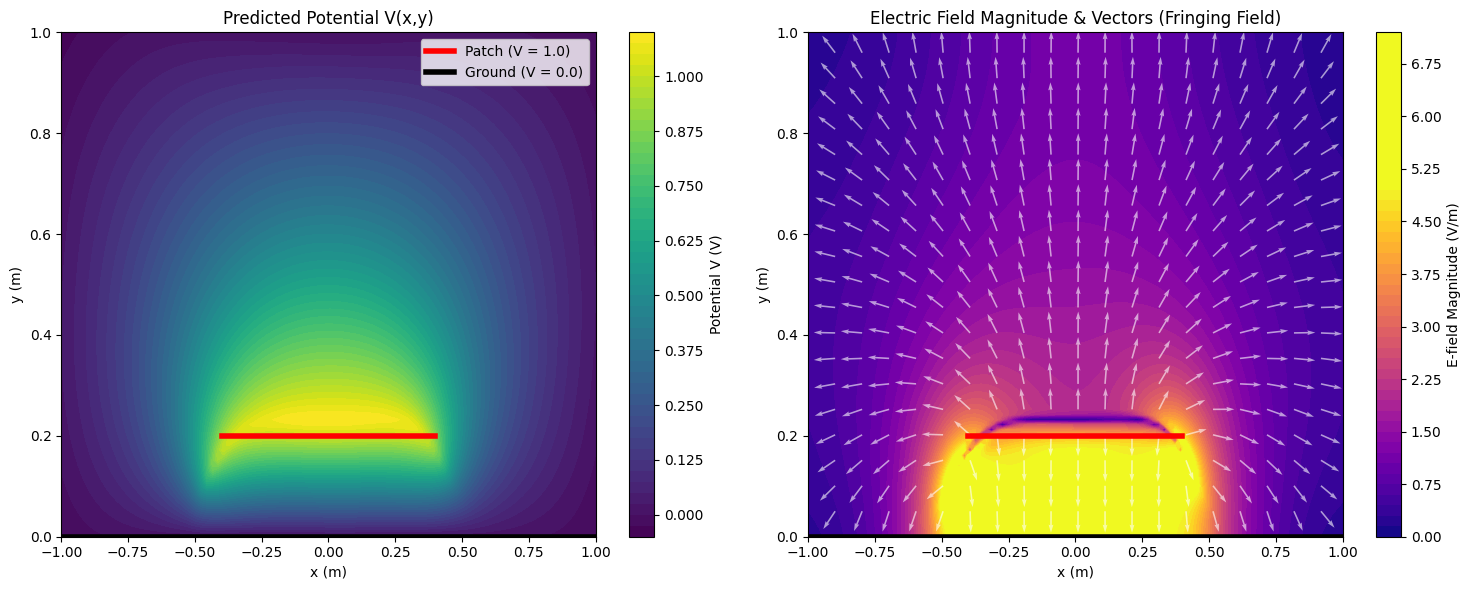


🎯 패치 및 도체 경계면에서의 경계조건 평균 오차 (MSE): 0.000191


In [16]:
# ==========================================
# 8. 전기장 계산 및 결과 시각화
# ==========================================

grid_tensor_eval = torch.FloatTensor(np.c_[X_mesh.ravel(), Y_mesh.ravel()])
grid_tensor_eval.requires_grad = True

# 1. 전위 값 및 1차 미분값 계산
V_pred_eval, _ = model_final(grid_tensor_eval)
grad_V = torch.autograd.grad(V_pred_eval, grid_tensor_eval, grad_outputs=torch.ones_like(V_pred_eval), create_graph=False)[0]

# E = -grad(V)
Ex = -grad_V[:, 0:1].detach().numpy().reshape(X_mesh.shape)
Ey = -grad_V[:, 1:2].detach().numpy().reshape(X_mesh.shape)
E_magnitude = np.sqrt(Ex**2 + Ey**2)

# 결과를 두 장의 사진 패널로 시각화한다
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 첫 번째 패널: 등전위선 분포 지도
contour_v = ax1.contourf(X_mesh, Y_mesh, V_pred_eval.detach().numpy().reshape(X_mesh.shape), levels=50, cmap='viridis')
fig.colorbar(contour_v, ax=ax1, label='Potential V (V)')
ax1.plot([-0.4, 0.4], [0.2, 0.2], 'r-', linewidth=4, label='Patch (V = 1.0)')
ax1.plot([-1.0, 1.0], [0.0, 0.0], 'k-', linewidth=4, label='Ground (V = 0.0)')
ax1.set_title("Predicted Potential V(x,y)")
ax1.set_xlabel("x (m)")
ax1.set_ylabel("y (m)")
ax1.legend(loc='upper right')

# 두 번째 패널: 전기장 벡터와 세기 분포
contour_e = ax2.contourf(X_mesh, Y_mesh, E_magnitude, levels=50, cmap='plasma', vmax=5.0)
fig.colorbar(contour_e, ax=ax2, label='E-field Magnitude (V/m)')

# 화살표 솎아내어(Subsampling) 그리기
sub = 5
ax2.quiver(X_mesh[::sub, ::sub], Y_mesh[::sub, ::sub], 
           Ex[::sub, ::sub] / (E_magnitude[::sub, ::sub] + 1e-8), 
           Ey[::sub, ::sub] / (E_magnitude[::sub, ::sub] + 1e-8), 
           color='white', alpha=0.6, scale=25)
ax2.plot([-0.4, 0.4], [0.2, 0.2], 'r-', linewidth=4, label='Patch')
ax2.plot([-1.0, 1.0], [0.0, 0.0], 'k-', linewidth=4, label='Ground')
ax2.set_title("Electric Field Magnitude & Vectors (Fringing Field)")
ax2.set_xlabel("x (m)")
ax2.set_ylabel("y (m)")

plt.tight_layout()
plt.show()

# 패치 안테나 금속선 부근에서의 정밀도를 오차율로 점검한다
with torch.no_grad():
    V_patch_pred, _ = model_final(X_u)
V_patch_pred = V_patch_pred.numpy()
V_patch_true = V_u.numpy()
pec_error = np.mean((V_patch_pred - V_patch_true)**2)

print(f"\n🎯 패치 및 도체 경계면에서의 경계조건 평균 오차 (MSE): {pec_error:.6f}")


## 9. [심화 학습] 패치 안테나의 3차원 방사 패턴 (3D Far-Field Radiation Pattern)

전자기학 Cavity Model 이론 공식에 근거하여 패치 안테나의 3차원 방사 지향성 패턴(Radiation Pattern)을 구현해 본다.  
패치의 기본 공진 상태($TM_{10}$ 모드)일 때, 방사 세기 강도 $R(\theta, \phi)$는 다음과 같다.  
$$R(\theta, \phi) = \left| \cos\theta \cdot \cos\left(\frac{k_0 L}{2} \sin\theta \cos\phi\right) \cdot \text{sinc}\left(\frac{k_0 W}{2} \sin\theta \sin\phi\right) \right|$$
- $\theta$: 고각 (Polar Angle, 접지판 위쪽 영역 $0 \le \theta \le 90^\circ$)
- $\phi$: 방위각 (Azimuth Angle, $0 \le \phi \le 360^\circ$)
- $L, W$: 안테나의 패치 길이 및 너비 (일반적으로 파장의 절반인 $0.5\lambda$ 정도로 설계된다)

안테나 윗방향인 하늘을 향해 강력한 빔이 형성되는지 3D 공간 표면 그래프로 확인해 본다.

In [ ]:
# ==========================================
# 9. 3차원 안테나 방사 패턴 모델링
# ==========================================

# 9-1. 구면 좌표 그리드 생성
theta_vec = np.linspace(0, np.pi/2, 100) # 반구 영역
phi_vec = np.linspace(0, 2*np.pi, 100)
THETA, PHI = np.meshgrid(theta_vec, phi_vec)

# 9-2. 안테나 물리 크기 파라미터 (L = 0.5 lambda, W = 0.5 lambda)
k0_L_2 = np.pi / 2
k0_W_2 = np.pi / 2

# numpy.sinc(x) = sin(pi*x)/(pi*x) 이므로, 수식 구현 시 pi를 나누어 적용합니다
X_arg = k0_W_2 * np.sin(THETA) * np.sin(PHI)
sinc_val = np.sinc(X_arg / np.pi)
cos_val = np.cos(k0_L_2 * np.sin(THETA) * np.cos(PHI))

# 지향성 강도 R 계산
R_intensity = np.abs(np.cos(THETA) * cos_val * sinc_val)

# 9-3. 구면 좌표계 -> 3차원 데카르트 좌표계(X, Y, Z) 변환
X_3d = R_intensity * np.sin(THETA) * np.cos(PHI)
Y_3d = R_intensity * np.sin(THETA) * np.sin(PHI)
Z_3d = R_intensity * np.cos(THETA)

# 9-4. Matplotlib 3D 표면도 플로팅
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 강도에 따른 Jet 컬러 코딩
norm_color = plt.Normalize(R_intensity.min(), R_intensity.max())
face_colors = plt.cm.jet(norm_color(R_intensity))

surf_plot = ax.plot_surface(X_3d, Y_3d, Z_3d, facecolors=face_colors, shade=True, edgecolor='none', alpha=0.9)

ax.set_title("3D Far-Field Radiation Pattern of Rectangular Patch Antenna", fontsize=13)
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Gain (Radiation Direction)')

# 각도 뷰 조절
ax.view_init(elev=30, azim=45)

# 컬러바 표기
mappable = plt.cm.ScalarMappable(cmap=plt.cm.jet, norm=norm_color)
mappable.set_array(R_intensity)
fig.colorbar(mappable, ax=ax, shrink=0.5, aspect=10, label='Normalized Radiation Gain')

plt.show()
